**E-Commerce Sales Data Analysis**

This project analyzes an e-commerce sales dataset containing 5,000 orders.

The analysis focuses on revenue, product categories, regions, payment methods,
delivery time, and customer ratings.

In [105]:
# Load Dataset
import pandas as pd
df= pd.read_csv("ecommerce_sales_analytics_5000.csv")


In [106]:
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [107]:
df.shape

(5000, 12)

In [108]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue'],
      dtype='object')

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


**Data Cleaning and Quality Check**

In [110]:
df.isnull().sum()

,0
order_id,0
order_date,0
customer_id,0
product_category,0
region,0
quantity,0
unit_price,0
discount,0
payment_method,0
delivery_days,0


In [111]:
df.duplicated().sum()

np.int64(0)

In [112]:
df.describe()

,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,1505.701200,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148
std,1443.520003,290.836902,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219
min,10001.000000,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000
25%,11250.750000,1253.000000,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500
50%,12500.500000,1510.000000,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000
75%,13750.250000,1761.000000,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000
max,15000.000000,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000


In [113]:
df.describe(include="object")

,order_date,product_category,region,payment_method
count,5000,5000,5000,5000
unique,5000,4,4,3
top,9/9/2035,Electronics,West,Card
freq,1,1777,1289,2270


In [114]:
df.nunique()

,0
order_id,5000
order_date,5000
customer_id,989
product_category,4
region,4
quantity,7
unit_price,4788
discount,36
payment_method,3
delivery_days,11


In [115]:
df["order_date"]=pd.to_datetime(df["order_date"])

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          5000 non-null   int64         
 1   order_date        5000 non-null   datetime64[ns]
 2   customer_id       5000 non-null   int64         
 3   product_category  5000 non-null   object        
 4   region            5000 non-null   object        
 5   quantity          5000 non-null   int64         
 6   unit_price        5000 non-null   float64       
 7   discount          5000 non-null   float64       
 8   payment_method    5000 non-null   object        
 9   delivery_days     5000 non-null   int64         
 10  customer_rating   5000 non-null   float64       
 11  revenue           5000 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(4), object(3)
memory usage: 468.9+ KB


In [117]:
total_orders = df["order_id"].nunique()
unique_customers = df["customer_id"].nunique()
total_revenue = df["revenue"].sum()
average_order_revenue = df["revenue"].mean()

print("Total Orders:", total_orders)
print("Unique Customers:", unique_customers)
print("Total Revenue:", round(total_revenue, 2))
print("Average Revenue per Order:", round(average_order_revenue, 2))

Total Orders: 5000
Unique Customers: 989
Total Revenue: 5109775.74
Average Revenue per Order: 1021.96


In [118]:
category_revenue=df.groupby("product_category")["revenue"].sum()
print(category_revenue)

product_category
Beauty          765860.88
Clothing       1531931.72
Electronics    1829899.22
Home            982083.92
Name: revenue, dtype: float64


In [119]:
category_revenue=category_revenue.sort_values(ascending=False)
print(category_revenue)

product_category
Electronics    1829899.22
Clothing       1531931.72
Home            982083.92
Beauty          765860.88
Name: revenue, dtype: float64


Electronics generated the highest revenue, while Beauty generated the lowest.

In [120]:
category_quantity=df.groupby("product_category")["quantity"].sum()
print(category_quantity.sort_values(ascending=False))

product_category
Electronics    7109
Clothing       6171
Home           3949
Beauty         2995
Name: quantity, dtype: int64


In [121]:
region_revenue=df.groupby("region")["revenue"].sum()
print(region_revenue.sort_values(ascending=False))

region
West     1345582.16
North    1281508.45
South    1246640.90
East     1236044.23
Name: revenue, dtype: float64


The West region had the highest revenue among the four regions.

In [122]:
region_quantity=df.groupby("region")["quantity"].sum()
print(region_quantity.sort_values(ascending=False))

region
West     5260
North    5164
East     4916
South    4884
Name: quantity, dtype: int64


In [123]:
region_orders=df["region"].value_counts()
print(region_orders)

region
West     1289
North    1276
East     1227
South    1208
Name: count, dtype: int64


In [124]:
payment_counts=df["payment_method"].value_counts()
print(payment_counts)

payment_method
Card      2270
COD       1774
Wallet     956
Name: count, dtype: int64


In [125]:
payment_revenue=df.groupby("payment_method")["revenue"].sum()
print(payment_revenue)

payment_method
COD       1788408.44
Card      2366248.20
Wallet     955119.10
Name: revenue, dtype: float64


In [126]:
delivery_by_region=df.groupby("region")["delivery_days"].mean()
print(delivery_by_region)

region
East     6.104319
North    6.118339
South    6.173013
West     6.082234
Name: delivery_days, dtype: float64


The average delivery time was about 6.12 days, and the differences between
regions were small.

In [127]:
delivery_summary=df["delivery_days"].describe()
print(delivery_summary)

count    5000.000000
mean        6.118800
std         3.153264
min         1.000000
25%         3.000000
50%         6.000000
75%         9.000000
max        11.000000
Name: delivery_days, dtype: float64


In [128]:
rating_counts=df["customer_rating"].value_counts().sort_index()
print(rating_counts)

customer_rating
1.0     80
1.1    121
1.2    119
1.3    125
1.4    134
1.5    129
1.6    122
1.7    143
1.8    127
1.9    115
2.0    129
2.1    116
2.2    149
2.3    137
2.4    133
2.5    119
2.6    127
2.7    119
2.8    112
2.9    121
3.0    128
3.1    137
3.2    139
3.3    107
3.4    116
3.5    137
3.6    133
3.7    111
3.8    121
3.9    125
4.0    105
4.1    133
4.2    116
4.3    122
4.4    126
4.5    108
4.6    124
4.7    118
4.8    126
4.9    118
5.0     73
Name: count, dtype: int64


In [129]:
rating_summary=df["customer_rating"].describe()
print(rating_summary)

count    5000.000000
mean        2.973980
std         1.157722
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: customer_rating, dtype: float64


In [130]:
rating_by_category=df.groupby("product_category")["customer_rating"].mean()
print(rating_by_category.sort_values(ascending=False))

product_category
Beauty         3.008990
Clothing       3.005095
Electronics    2.951097
Home           2.940660
Name: customer_rating, dtype: float64


In [131]:
print("Start Date:", df["order_date"].min())
print("End Date:", df["order_date"].max())

Start Date: 2022-01-01 00:00:00
End Date: 2035-09-09 00:00:00


In [132]:
monthly_revenue=df.groupby(df["order_date"].dt.to_period("M"))["revenue"].sum()
print(monthly_revenue)

order_date
2022-01    35624.89
2022-02    29908.89
2022-03    30309.28
2022-04    30781.96
2022-05    41629.24
             ...   
2035-05    33393.87
2035-06    25205.26
2035-07    23944.48
2035-08    29354.74
2035-09     4952.23
Freq: M, Name: revenue, Length: 165, dtype: float64


In [133]:
monthly_orders=df.groupby(df["order_date"].dt.to_period("M"))["order_id"].count()
print(monthly_orders)

order_date
2022-01    31
2022-02    28
2022-03    31
2022-04    30
2022-05    31
           ..
2035-05    31
2035-06    30
2035-07    31
2035-08    31
2035-09     9
Freq: M, Name: order_id, Length: 165, dtype: int64


**Visualization**

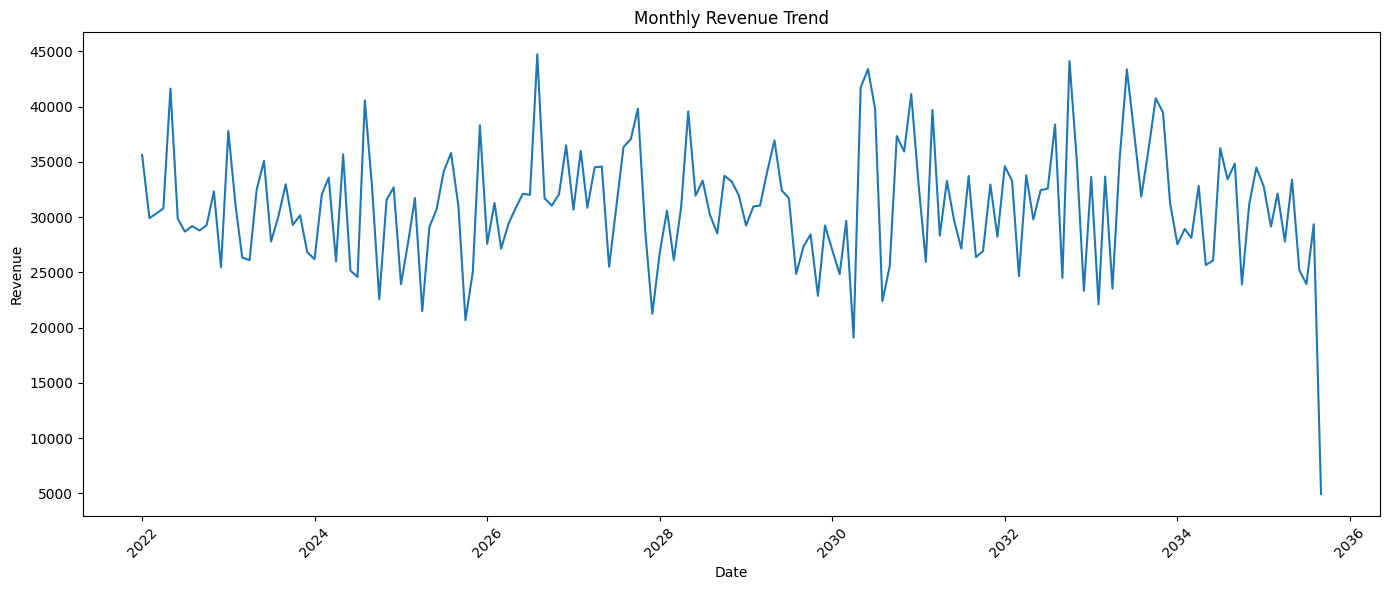

In [134]:
import matplotlib.pyplot as plt

monthly_revenue=df.groupby(df["order_date"].dt.to_period("M"))["revenue"].sum()

monthly_revenue.index=monthly_revenue.index.to_timestamp()

plt.figure(figsize=(14,6))

plt.plot(monthly_revenue.index, monthly_revenue.values)

plt.title("Monthly Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

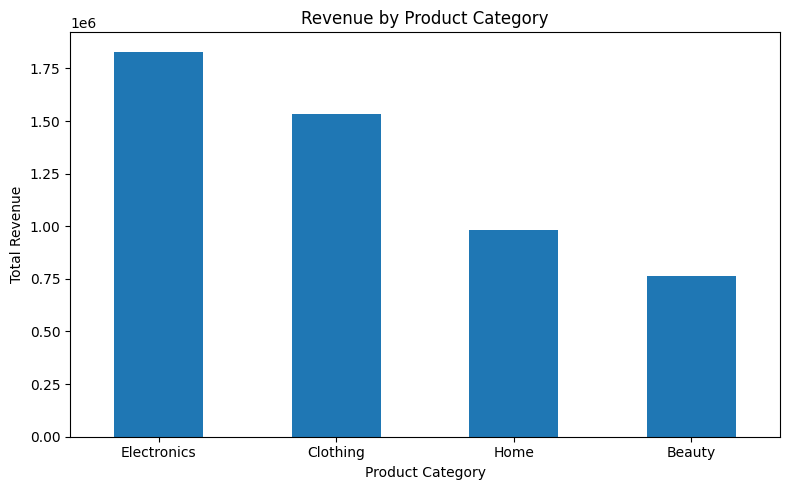

In [135]:
category_revenue=df.groupby("product_category")["revenue"].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))

category_revenue.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


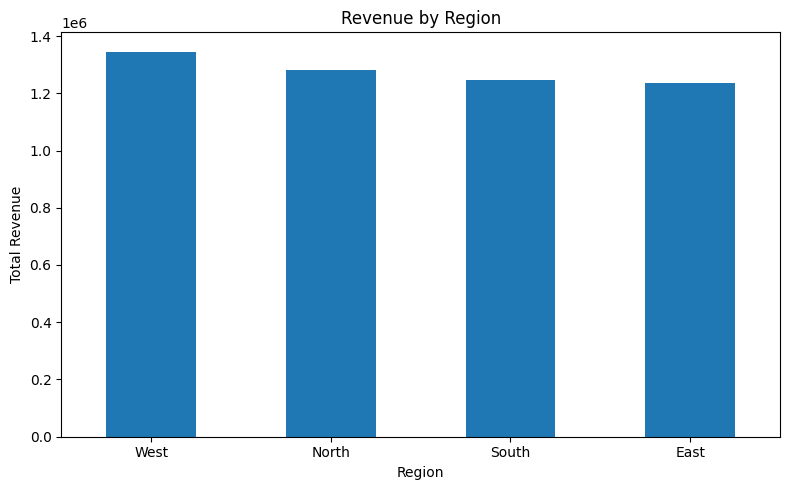

In [136]:
region_revenue=df.groupby("region")["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

region_revenue.plot(kind="bar")

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


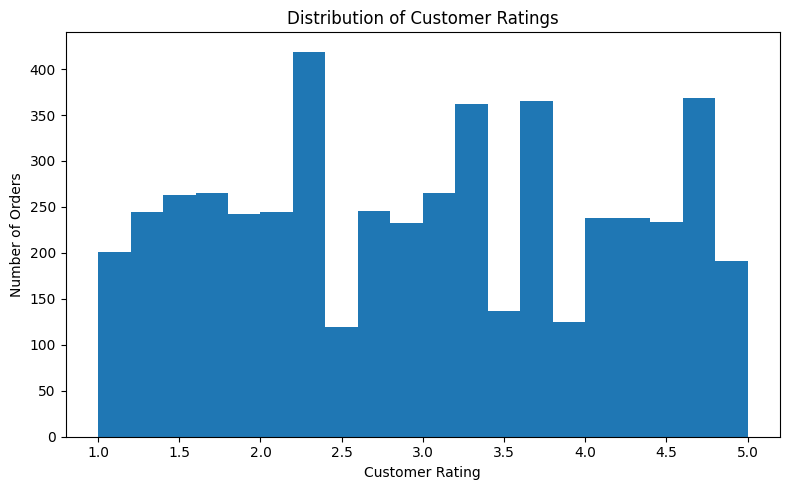

In [137]:
plt.figure(figsize=(8,5))

plt.hist(df["customer_rating"], bins=20)

plt.title("Distribution of Customer Ratings")
plt.xlabel("Customer Rating")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

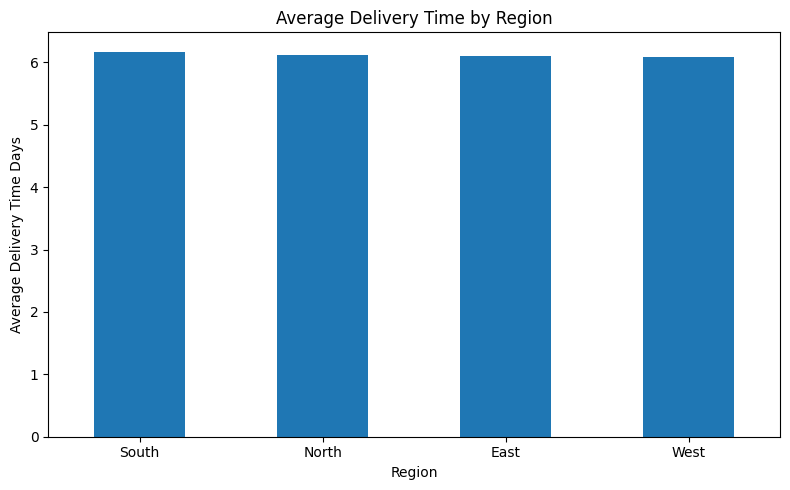

In [138]:
delivery_by_region=df.groupby("region")["delivery_days"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))

delivery_by_region.plot(kind="bar")

plt.title("Average Delivery Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Delivery Time Days")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()